<a href="https://colab.research.google.com/github/urmilapol/urmilapolprojects/blob/master/AutoEDA_Titanic_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project 2: Automated EDA (AutoEDA)

**Dataset:** Titanic  
**Platform:** Google Colab  

This notebook uses `ydata-profiling` to automatically generate a detailed EDA report.

## Learning Objectives
- Load a real-world dataset
- Inspect data quality
- Generate an automated EDA report
- Examine missing values, distributions and correlations
- Perform feature engineering
- Compare manual EDA with AutoEDA

In [1]:
!pip -q install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

sns.set_theme()
print('Libraries imported successfully.')

Libraries imported successfully.


/tmp/ipykernel_531/2405441256.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 1. Load the Titanic Dataset

In [3]:
df = sns.load_dataset('titanic')
display(df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Basic Inspection

In [4]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nData types and non-null values:')
df.info()

Shape: (891, 15)

Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 

## 3. Missing Values and Duplicates

In [5]:
print('Missing values:')
display(df.isnull().sum().sort_values(ascending=False))

print('Duplicate rows:', df.duplicated().sum())

Missing values:


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


Duplicate rows: 107


## 4. Generate the AutoEDA Report

In [6]:
profile = ProfileReport(
    df,
    title='Titanic Dataset - Automated EDA Report',
    explorative=True
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 38.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### What does the AutoEDA report provide?
- Dataset overview
- Variable types
- Missing values
- Descriptive statistics
- Histograms and distributions
- Correlations
- Duplicate analysis
- Warnings and possible data-quality issues

In [7]:
# Save the complete report as an HTML file
profile.to_file('titanic_autoeda_report.html')
print('Report saved as titanic_autoeda_report.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report saved as titanic_autoeda_report.html


## 5. Verify Important Findings Manually

In [8]:
print('Descriptive statistics:')
display(df.describe(include='all').T)

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False))

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,0
deck,688
age,177
embarked,2
embark_town,2
sex,0
pclass,0
survived,0
fare,0
parch,0
sibsp,0


## 6. Visual Analysis

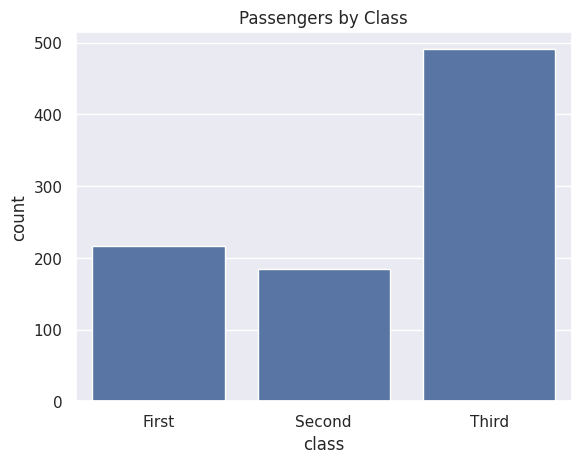

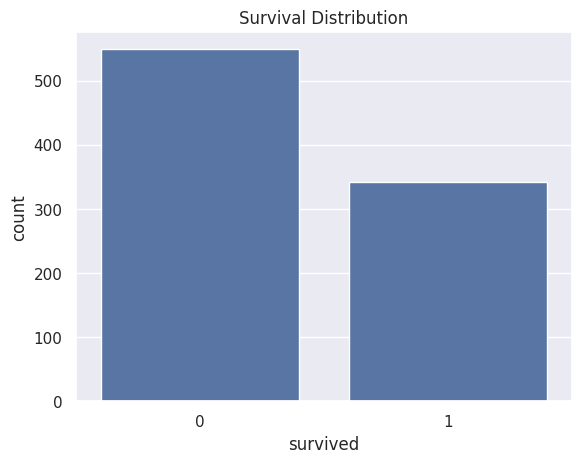

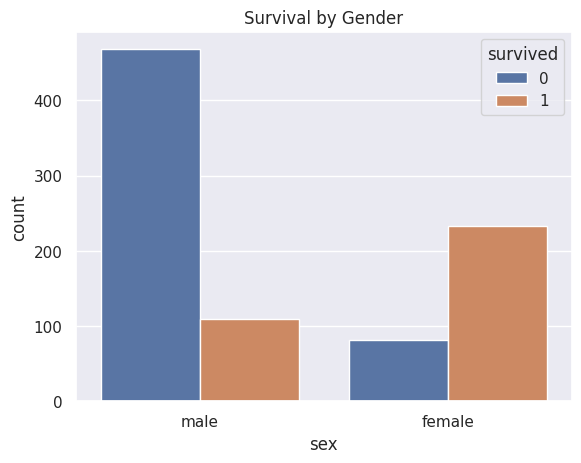

In [9]:
sns.countplot(data=df, x='class')
plt.title('Passengers by Class')
plt.show()

sns.countplot(data=df, x='survived')
plt.title('Survival Distribution')
plt.show()

sns.countplot(data=df, x='sex', hue='survived')
plt.title('Survival by Gender')
plt.show()

## 7. Correlation Analysis

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


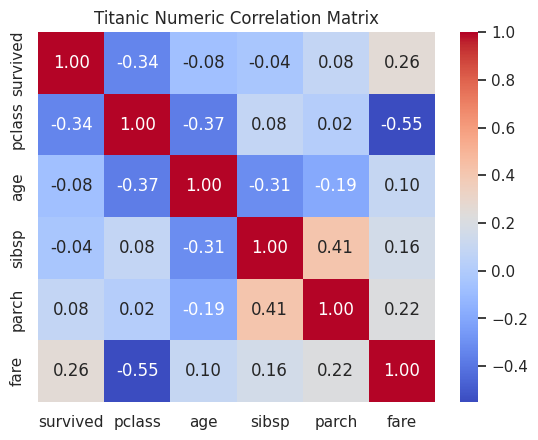

In [10]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
display(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Titanic Numeric Correlation Matrix')
plt.show()

## 8. Feature Engineering

In [11]:
# FamilySize = number of siblings/spouses + parents/children + passenger
df['FamilySize'] = df['sibsp'] + df['parch'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

display(df[['sibsp', 'parch', 'FamilySize', 'IsAlone']].head(10))

,sibsp,parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


## 9. Run AutoEDA Again After Feature Engineering

In [12]:
profile2 = ProfileReport(
    df,
    title='Titanic Dataset - AutoEDA After Feature Engineering',
    explorative=True
)

profile2.to_notebook_iframe()
profile2.to_file('titanic_autoeda_after_feature_engineering.html')
print('Second report saved as titanic_autoeda_after_feature_engineering.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 38.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Second report saved as titanic_autoeda_after_feature_engineering.html


## 10. Student Discussion Questions
1. Which variables contain missing values?
2. Which passenger class has the most passengers?
3. What relationship can you observe between gender and survival?
4. What information is added by `FamilySize`?
5. What is the difference between manual EDA and AutoEDA?
6. Why should an AutoEDA report be interpreted rather than blindly accepted?

**Conclusion:** AutoEDA greatly reduces the time required for initial data exploration, while manual EDA remains important for understanding business/research questions and validating automated findings.